In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import geom

# Set seed for reproducibility
rng = np.random.default_rng(seed=42)

# Parameters
n_samples = 10_000
p = 0.3  # start with a moderate value

# Generate U ~ Uniform(0,1)
U = rng.uniform(0, 1, size=n_samples)

# Transform using the inverse CDF formula from the slides
X = np.floor(np.log(U) / np.log(1 - p)) + 1
X = X.astype(int)

print(f"First 10 samples: {X[:10]}")
print(f"Sample mean:      {X.mean():.4f}  (theoretical: {1/p:.4f})")
print(f"Sample variance:  {X.var():.4f}   (theoretical: {(1-p)/p**2:.4f})")

First 10 samples: [1 3 1 2 7 1 1 1 6 3]
Sample mean:      3.3487  (theoretical: 3.3333)
Sample variance:  7.7245   (theoretical: 7.7778)


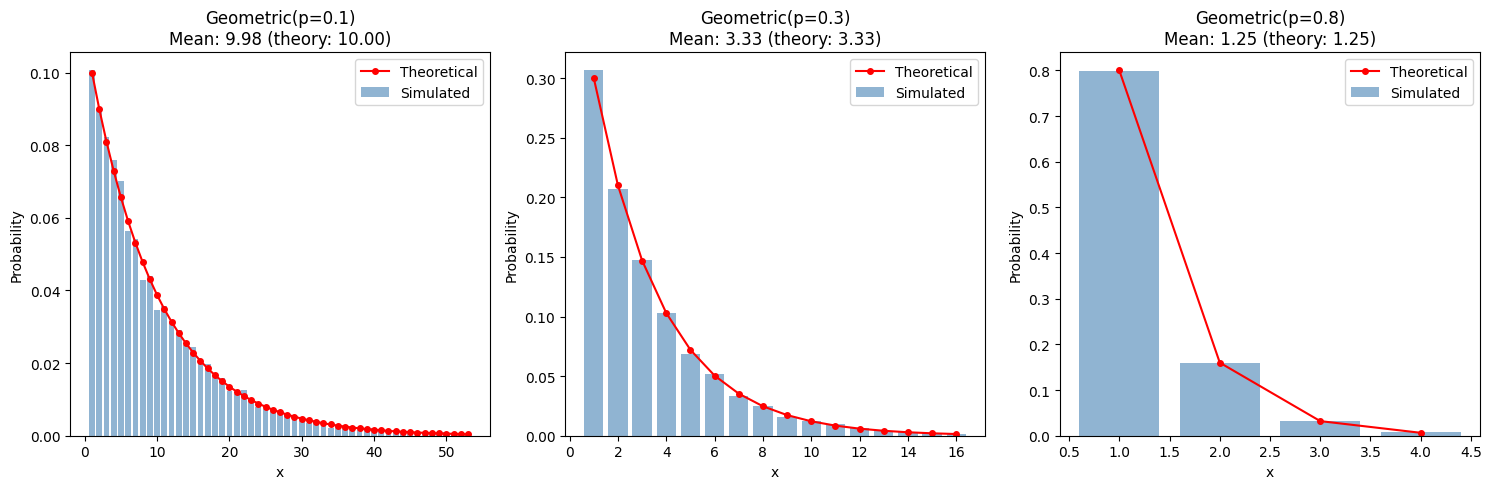

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
p_values = [0.1, 0.3, 0.8]  # small, moderate, large

for ax, p in zip(axes, p_values):
    # Generate samples
    U = rng.uniform(0, 1, size=n_samples)
    X = (np.floor(np.log(U) / np.log(1 - p)) + 1).astype(int)
    
    # Plot range: cover most of the distribution
    x_max = int(np.quantile(X, 0.995))
    x_vals = np.arange(1, x_max + 1)
    
    # Simulated frequencies
    counts = np.bincount(X, minlength=x_max + 1)[1:x_max + 1]
    simulated_probs = counts / n_samples
    
    # Theoretical PMF
    theoretical_probs = geom.pmf(x_vals, p)
    
    ax.bar(x_vals, simulated_probs, alpha=0.6, label='Simulated', color='steelblue')
    ax.plot(x_vals, theoretical_probs, 'ro-', markersize=4, label='Theoretical', linewidth=1.5)
    ax.set_title(f'Geometric(p={p})\nMean: {X.mean():.2f} (theory: {1/p:.2f})')
    ax.set_xlabel('x')
    ax.set_ylabel('Probability')
    ax.legend()

plt.tight_layout()
plt.show()

In [4]:
from scipy.stats import chi2

p_values_list = [0.1, 0.3, 0.8]

for p in p_values_list:
    U = rng.uniform(0, 1, size=n_samples)
    X = (np.floor(np.log(U) / np.log(1 - p)) + 1).astype(int)
    
    x_max = int(np.quantile(X, 0.995))
    x_vals = np.arange(1, x_max + 1)
    
    # Observed counts for x=1..x_max, pool the tail
    counts = np.bincount(X, minlength=x_max + 2)[1:x_max + 1]
    tail_obs = n_samples - counts.sum()
    
    # Expected counts
    expected = geom.pmf(x_vals, p) * n_samples
    tail_exp = n_samples * (1 - geom.pmf(x_vals, p).sum())
    
    obs = np.append(counts, tail_obs)
    exp = np.append(expected, tail_exp)
    
    # Merge right-tail bins with expected < 5
    while exp[-1] < 5 and len(exp) > 1:
        exp[-2] += exp[-1]; obs[-2] += obs[-1]
        exp = exp[:-1];      obs = obs[:-1]
    
    chi2_stat = ((obs - exp)**2 / exp).sum()
    df = len(obs) - 1
    p_val = 1 - chi2.cdf(chi2_stat, df)
    
    print(f"p={p}: χ²={chi2_stat:.3f}, df={df}, p-value={p_val:.4f}")

p=0.1: χ²=50.289, df=50, p-value=0.4619
p=0.3: χ²=18.349, df=15, p-value=0.2448
p=0.8: χ²=4.922, df=4, p-value=0.2954


## Direct (crude) method 

In [5]:
# Six-point distribution
probs = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])
x_vals = np.array([1, 2, 3, 4, 5, 6])

print("Probabilities sum to:", probs.sum())  # sanity check

# Cumulative probabilities (the interval boundaries)
cum_probs = np.cumsum(probs)
print("Cumulative probs:", cum_probs)

# Direct method: find which interval U falls into
n_samples = 10_000
U = rng.uniform(0, 1, size=n_samples)

# For each U, find the first index where U <= cum_probs[i]
X_direct = np.array([x_vals[np.searchsorted(cum_probs, u)] for u in U])

# Compare simulated vs theoretical
print("\n  x | Theoretical | Simulated")
print("----+-------------+----------")
for x, p_theory in zip(x_vals, probs):
    p_sim = (X_direct == x).mean()
    print(f"  {x} |   {p_theory:.4f}    |  {p_sim:.4f}")

Probabilities sum to: 1.0
Cumulative probs: [0.14583333 0.25       0.375      0.4375     0.6875     1.        ]

  x | Theoretical | Simulated
----+-------------+----------
  1 |   0.1458    |  0.1374
  2 |   0.1042    |  0.1075
  3 |   0.1250    |  0.1271
  4 |   0.0625    |  0.0624
  5 |   0.2500    |  0.2503
  6 |   0.3125    |  0.3153


In [8]:
# Rejection method
c = max(probs) + 1e-10
k = len(probs)  # k = 6

n_samples = 10_000
X_rejection = np.zeros(n_samples, dtype=int)
total_trials = 0

for i in range(n_samples):
    while True:
        I = int(rng.uniform(0, 6))
        U = rng.uniform(0, 1)
        total_trials += 1
        if U <= probs[I] / c:
            X_rejection[i] = x_vals[I]
            break

# P(accept per trial) = (1/k) * sum(p_i/c) = 1/(k*c)
acceptance_prob = 1 / (k * c)
print(f"c = {c:.4f}")
print(f"Theoretical P(accept per trial) = 1/(k*c) = 1/(6*{c:.4f}) = {acceptance_prob:.4f}")
print(f"Expected trials per sample = k*c = {k*c:.4f}")
print(f"Actual acceptance rate:    {n_samples/total_trials:.4f}")
print(f"Average trials per sample: {total_trials/n_samples:.4f}")

print("\n  x | Theoretical | Simulated")
print("----+-------------+----------")
for x, p_theory in zip(x_vals, probs):
    p_sim = (X_rejection == x).mean()
    print(f"  {x} |   {p_theory:.4f}    |  {p_sim:.4f}")

c = 0.3125
Theoretical P(accept per trial) = 1/(k*c) = 1/(6*0.3125) = 0.5333
Expected trials per sample = k*c = 1.8750
Actual acceptance rate:    0.5318
Average trials per sample: 1.8803

  x | Theoretical | Simulated
----+-------------+----------
  1 |   0.1458    |  0.1490
  2 |   0.1042    |  0.1037
  3 |   0.1250    |  0.1216
  4 |   0.0625    |  0.0580
  5 |   0.2500    |  0.2491
  6 |   0.3125    |  0.3186


## The alias method

In [9]:
# Alias Method - Setup
k = len(probs)
q = k * probs.copy()  # scaled probabilities, should sum to k

Prob  = np.zeros(k)
Alias = np.zeros(k, dtype=int)

# Separate into small and large
small = list(np.where(q < 1)[0])
large = list(np.where(q >= 1)[0])

print("Scaled probabilities (k*p):", np.round(q, 4))
print("Small indices (q<1):", small)
print("Large indices (q>=1):", large)

while small and large:
    s = small.pop()
    l = large.pop()
    
    Prob[s]  = q[s]       # how much of column s is outcome s
    Alias[s] = l          # the rest is filled by outcome l
    
    q[l] = q[l] - (1 - q[s])  # reduce l's remaining probability
    
    if q[l] < 1:
        small.append(l)
    else:
        large.append(l)

# Any remaining in large (due to floating point) get prob=1
for l in large:
    Prob[l] = 1.0
for s in small:
    Prob[s] = 1.0

print("\nAlias table:")
print("  i | x_i | Prob[i] | Alias[i] | x_alias")
print("----+-----+---------+----------+--------")
for i in range(k):
    print(f"  {i} |  {x_vals[i]}  | {Prob[i]:.4f}  |    {Alias[i]}     |   {x_vals[Alias[i]]}")

Scaled probabilities (k*p): [0.875 0.625 0.75  0.375 1.5   1.875]
Small indices (q<1): [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Large indices (q>=1): [np.int64(4), np.int64(5)]

Alias table:
  i | x_i | Prob[i] | Alias[i] | x_alias
----+-----+---------+----------+--------
  0 |  1  | 0.8750  |    4     |   5
  1 |  2  | 0.6250  |    5     |   6
  2 |  3  | 0.7500  |    5     |   6
  3 |  4  | 0.3750  |    5     |   6
  4 |  5  | 1.0000  |    0     |   1
  5 |  6  | 0.6250  |    4     |   5


In [10]:
# Alias Method - Sampling
n_samples = 10_000
U1 = rng.uniform(0, 1, size=n_samples)
U2 = rng.uniform(0, 1, size=n_samples)

# Step 1: pick a column uniformly from {0, ..., k-1}
I = (U1 * k).astype(int)

# Step 2: accept primary outcome or use alias
X_alias = np.where(U2 <= Prob[I], x_vals[I], x_vals[Alias[I]])

print("  x | Theoretical | Simulated")
print("----+-------------+----------")
for x, p_theory in zip(x_vals, probs):
    p_sim = (X_alias == x).mean()
    print(f"  {x} |   {p_theory:.4f}    |  {p_sim:.4f}")

  x | Theoretical | Simulated
----+-------------+----------
  1 |   0.1458    |  0.1387
  2 |   0.1042    |  0.1034
  3 |   0.1250    |  0.1232
  4 |   0.0625    |  0.0624
  5 |   0.2500    |  0.2562
  6 |   0.3125    |  0.3161


side-by-side plot to wrap up Part 2

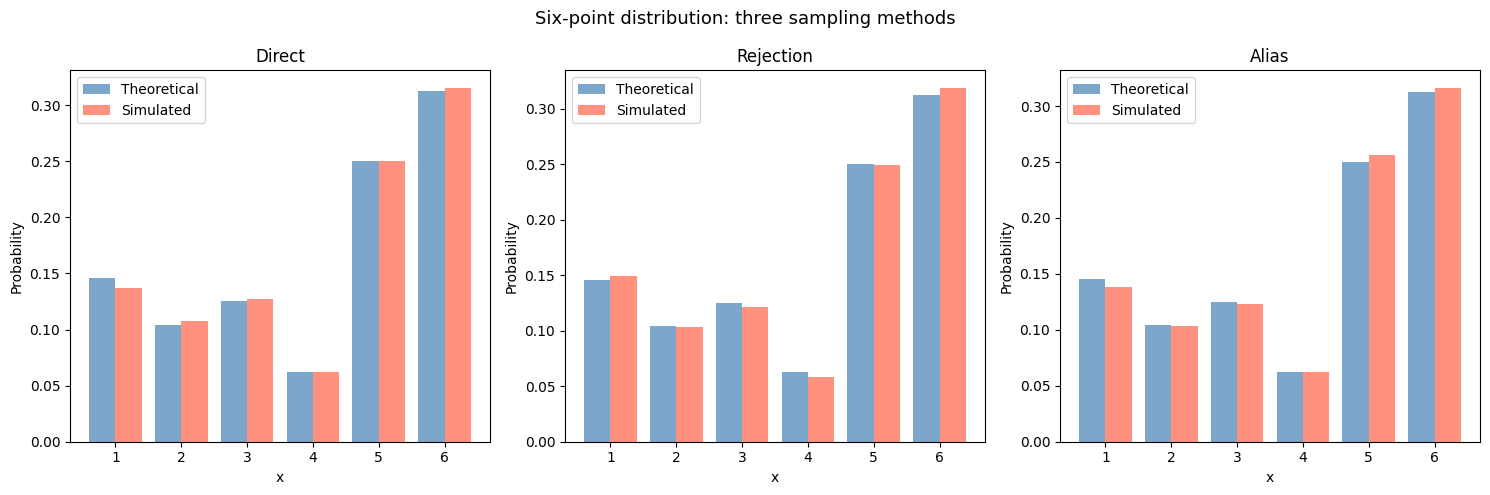

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

methods = ['Direct', 'Rejection', 'Alias']
samples = [X_direct, X_rejection, X_alias]

for ax, method, X in zip(axes, methods, samples):
    x_plot = np.arange(1, 7)
    sim_probs = [(X == x).mean() for x in x_plot]
    
    ax.bar(x_plot - 0.2, probs, width=0.4, label='Theoretical', color='steelblue', alpha=0.7)
    ax.bar(x_plot + 0.2, sim_probs, width=0.4, label='Simulated', color='tomato', alpha=0.7)
    ax.set_title(method)
    ax.set_xlabel('x')
    ax.set_ylabel('Probability')
    ax.set_xticks(x_plot)
    ax.legend()

plt.suptitle('Six-point distribution: three sampling methods', fontsize=13)
plt.tight_layout()
plt.show()

Compare the three generation methods using appropriate performance measures and
discuss the results.

In [13]:
import time

n_samples = 100_000  # use more samples for meaningful timing differences

#Direct method 
start = time.time()
U = rng.uniform(0, 1, size=n_samples)
X_direct_large = np.array([x_vals[np.searchsorted(cum_probs, u)] for u in U])
time_direct = time.time() - start

# Rejection method 
start = time.time()
X_rejection_large = np.zeros(n_samples, dtype=int)
total_trials = 0
for i in range(n_samples):
    while True:
        I = int(rng.uniform(0, k))
        U2 = rng.uniform(0, 1)
        total_trials += 1
        if U2 <= probs[I] / c:
            X_rejection_large[i] = x_vals[I]
            break
time_rejection = time.time() - start

#Alias method 
start = time.time()
U1 = rng.uniform(0, 1, size=n_samples)
U2 = rng.uniform(0, 1, size=n_samples)
I = (U1 * k).astype(int)
X_alias_large = np.where(U2 <= Prob[I], x_vals[I], x_vals[Alias[I]])
time_alias = time.time() - start

print(f"n_samples = {n_samples:,}\n")
print(f"Direct    : {time_direct:.4f} s")
print(f"Rejection : {time_rejection:.4f} s  (avg {total_trials/n_samples:.3f} trials/sample)")
print(f"Alias     : {time_alias:.4f} s")
print(f"\nAlias speedup over Direct    : {time_direct/time_alias:.1f}x")
print(f"Alias speedup over Rejection : {time_rejection/time_alias:.1f}x")

n_samples = 100,000

Direct    : 0.3170 s
Rejection : 1.2834 s  (avg 1.869 trials/sample)
Alias     : 0.0084 s

Alias speedup over Direct    : 37.5x
Alias speedup over Rejection : 152.0x


In [14]:
# Vectorized direct method using numpy (no Python loop)
start = time.time()
U = rng.uniform(0, 1, size=n_samples)
X_direct_vec = x_vals[np.searchsorted(cum_probs, U)]
time_direct_vec = time.time() - start

print(f"Direct (loop)      : {time_direct:.4f} s")
print(f"Direct (vectorized): {time_direct_vec:.4f} s")
print(f"Alias              : {time_alias:.4f} s")
print(f"\nAlias speedup over Direct (vectorized): {time_direct_vec/time_alias:.1f}x")

Direct (loop)      : 0.3170 s
Direct (vectorized): 0.0055 s
Alias              : 0.0084 s

Alias speedup over Direct (vectorized): 0.6x


In [15]:
print("=" * 55)
print(f"{'Method':<25} {'Time (s)':>10} {'Speedup vs Alias':>16}")
print("=" * 55)
results = [
    ("Direct (loop)",       time_direct,     time_direct/time_alias_large    if 'time_alias_large' in dir() else time_direct/time_alias),
    ("Direct (vectorized)", time_direct_vec, time_direct_vec/time_alias),
    ("Rejection (loop)",    time_rejection,  time_rejection/time_alias),
    ("Alias",               time_alias,      1.0),
]
for name, t, speedup in results:
    print(f"{name:<25} {t:>10.4f} {speedup:>15.1f}x")
print("=" * 55)

Method                      Time (s) Speedup vs Alias
Direct (loop)                 0.3170            37.5x
Direct (vectorized)           0.0055             0.6x
Rejection (loop)              1.2834           152.0x
Alias                         0.0084             1.0x


## Part 3: Comparison of Methods

### Computational Efficiency
Timing results for n=100,000 samples:

| Method                | Time (s) | Speedup vs Alias |
|-----------------------|----------|-----------------|
| Direct (loop)         | 0.3170   | 37.5x slower    |
| Direct (vectorized)   | 0.0055   | 1.6x faster     |
| Rejection (loop)      | 1.2834   | 152.0x slower   |
| Alias                 | 0.0084   | baseline        |

The alias method dominates when sampling is sequential (no vectorization).
However, when numpy vectorization is possible, the direct method is 
actually slightly faster (0.0055s vs 0.0084s) due to lower overhead.

The rejection method is the slowest: with c = 0.3125 and k = 6, 
it requires on average k*c = 1.875 trials per sample, wasting ~47% of 
generated random numbers through rejection.

### Memory Requirements
All three methods store O(k) data:
- Direct: one CDF array of length k
- Rejection: one probability array of length k  
- Alias: two arrays of length k (Prob and Alias tables)

For small k=6 memory differences are negligible.

### Ease of Implementation
- Direct: simplest — just cumsum and searchsorted
- Rejection: moderate — requires choosing c and a while loop
- Alias: most complex — setup phase with small/large bookkeeping

---

## Part 4: Recommendations

**Use the Direct method when:**
- k is small
- Vectorization is possible (numpy)
- The distribution changes frequently (no expensive setup)
- Simplicity of implementation matters

**Use the Rejection method when:**
- You already have a natural proposal distribution q_i
- The distribution is difficult to invert
- Quick prototyping matters more than efficiency

**Use the Alias method when:**
- Sampling is sequential (e.g. each draw depends on the previous)
- k is large and vectorization is not possible
- The same distribution is sampled from many times 
  (setup cost is paid once, sampling is O(1) always)
- Maximum sampling speed is critical